# Классификация персонажей One Piece с помощью CNN
## ResNet50 vs EfficientNetB0 (PyTorch)

**Задача:** 18-классовая классификация персонажей аниме One Piece

## 0. Установка зависимостей

Выполните в терминале:

**CPU (любой ПК):**
```
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
pip install matplotlib scikit-learn seaborn numpy pandas pillow opencv-python tqdm
```

**GPU NVIDIA (CUDA 11.8):**
```
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
pip install matplotlib scikit-learn seaborn numpy pandas pillow opencv-python tqdm
```

## 1. Импорты и конфигурация

In [5]:
import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights
from tqdm import tqdm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

: 

## 2. Конфигурация датасета

**⬇ Укажите путь к датасету в переменной DATASET_PATH**

In [4]:
import kagglehub

# Download latest version
DATASET_PATH = kagglehub.dataset_download("ibrahimserouis99/one-piece-image-classifier")

print("Path to dataset files:", DATASET_PATH)

CLASS_NAMES = [
    'Ace','Akainu','Brook','Chopper','Crocodile',
    'Franky','Jinbei','Kurohige','Law','Luffy',
    'Mihawk','Nami','Rayleigh','Robin','Sanji',
    'Shanks','Usopp','Zoro'
]

IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_CLASSES   = 18
EPOCHS_STAGE1 = 15
LR_STAGE1     = 1e-3
EPOCHS_STAGE2 = 15
LR_STAGE2     = 1e-5
UNFREEZE_N    = 30

print(f'Dataset    : {DATASET_PATH}')
print(f'Image size : {IMG_SIZE}x{IMG_SIZE}  Batch: {BATCH_SIZE}  Classes: {NUM_CLASSES}')

 54%|█████▍    | 1.37G/2.53G [02:28<02:05, 9.90MB/s]


ChunkedEncodingError: ('Connection broken: IncompleteRead(1474346486 bytes read, 1243873104 more expected)', IncompleteRead(1474346486 bytes read, 1243873104 more expected))

## 3. EDA — анализ данных

In [ ]:
dataset_dir = Path(DATASET_PATH)

class_counts = {}
for cls in CLASS_NAMES:
    d = dataset_dir / cls
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.png')) + list(d.glob('*.jpeg')) if d.exists() else []
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())
print(f'Всего изображений: {total_images}')
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f'  {cls:<12}: {cnt:>5}')

Всего изображений: 11737
  Nami        :   665
  Zoro        :   659
  Brook       :   657
  Luffy       :   654
  Akainu      :   651
  Crocodile   :   651
  Franky      :   651
  Jinbei      :   651
  Law         :   651
  Mihawk      :   651
  Rayleigh    :   651
  Robin       :   651
  Sanji       :   651
  Shanks      :   651
  Ace         :   648
  Chopper     :   648
  Kurohige    :   648
  Usopp       :   648


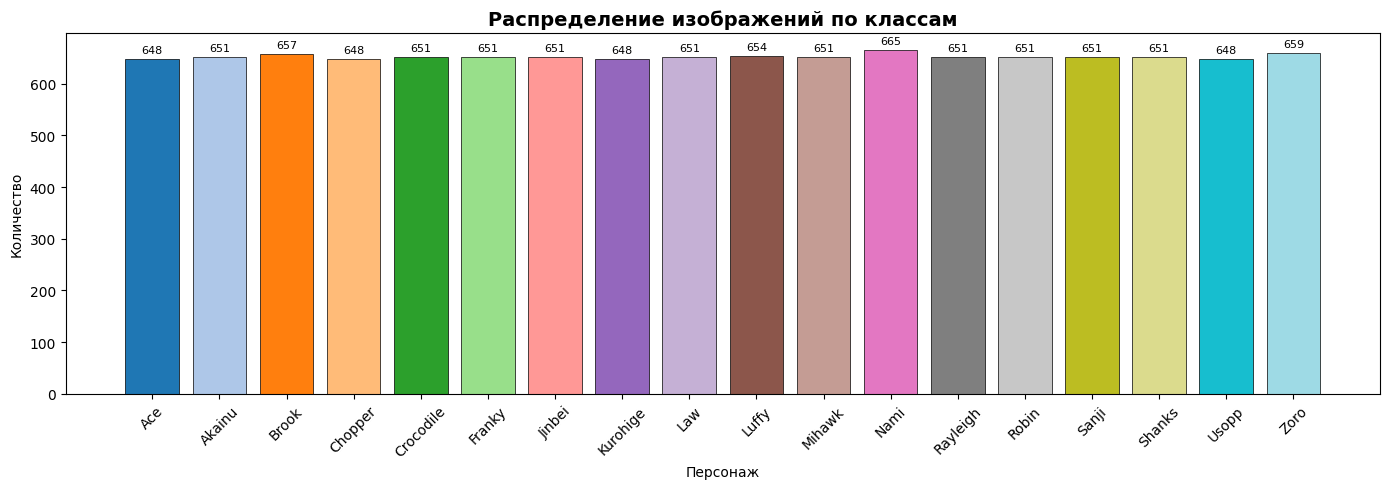

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))
colors = plt.cm.tab20(np.linspace(0,1,NUM_CLASSES))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', lw=0.5)
for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, str(val), ha='center', va='bottom', fontsize=8)
ax.set_title('Распределение изображений по классам', fontsize=14, fontweight='bold')
ax.set_xlabel('Персонаж'); ax.set_ylabel('Количество'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

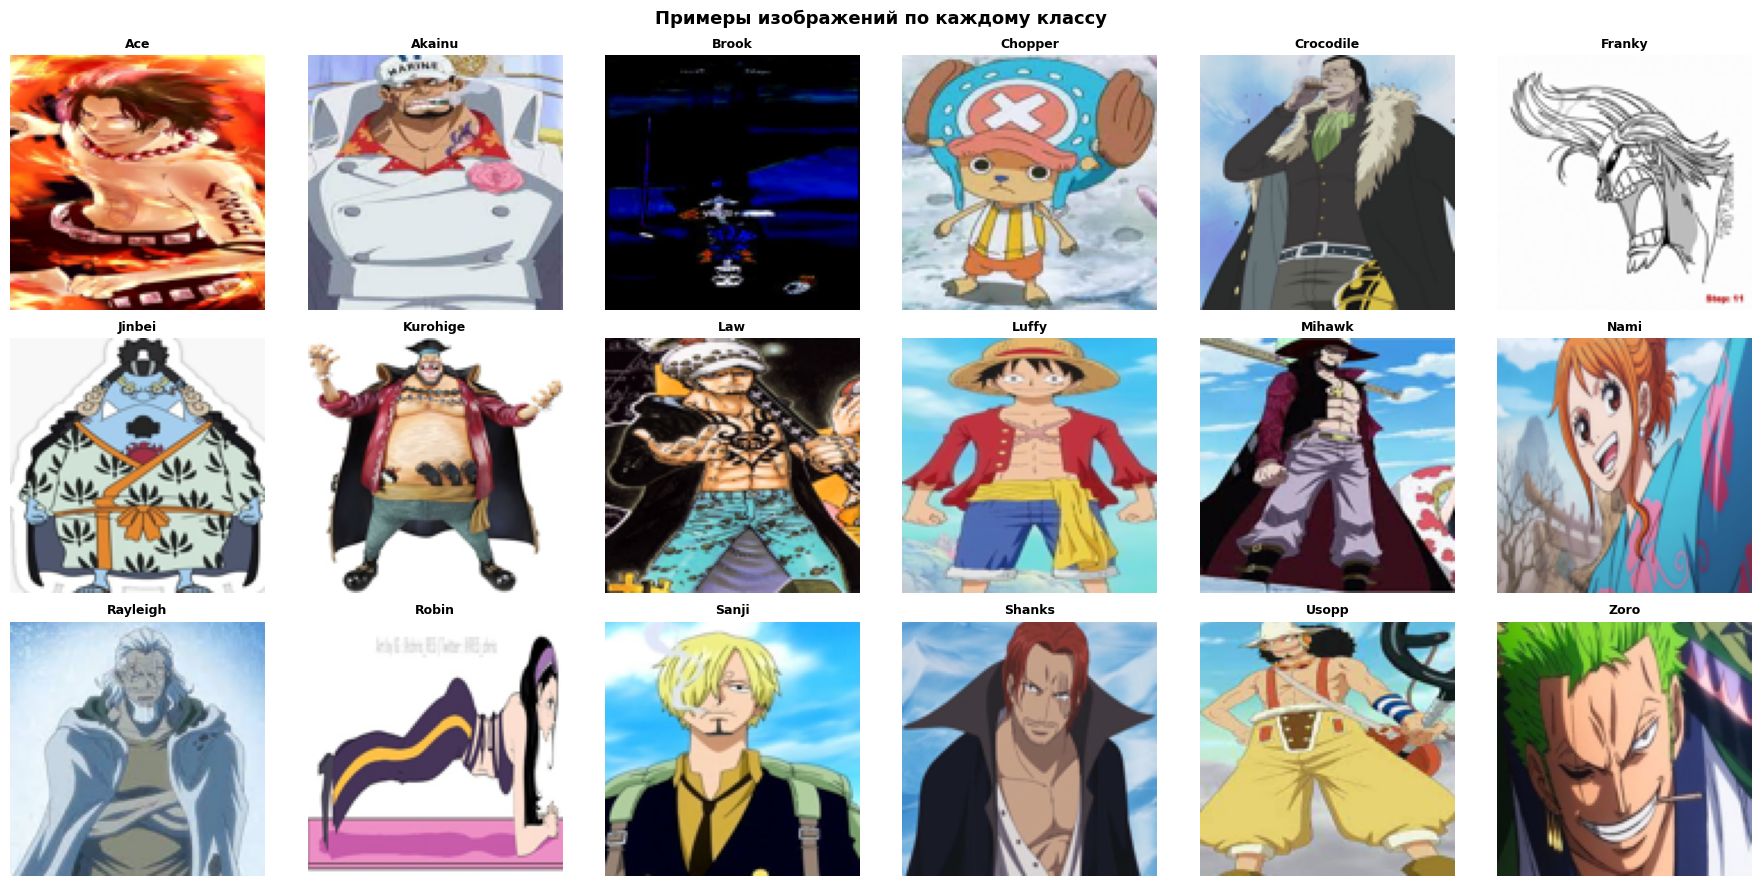

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(18,9))
for idx, cls in enumerate(CLASS_NAMES):
    d = dataset_dir / cls
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.png')) + list(d.glob('*.jpeg'))
    ax = axes[idx // 6][idx % 6]
    if imgs: ax.imshow(Image.open(imgs[0]).convert('RGB').resize((112,112)))
    ax.set_title(cls, fontsize=9, fontweight='bold'); ax.axis('off')
plt.suptitle('Примеры изображений по каждому классу', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('sample_images.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Подготовка данных и аугментация

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15,0.15), shear=10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85,1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

full_ds = datasets.ImageFolder(DATASET_PATH)
n_total = len(full_ds)
n_val   = int(0.2 * n_total)
n_train = n_total - n_val

gen = torch.Generator().manual_seed(SEED)
indices = torch.randperm(n_total, generator=gen).tolist()
train_idx, val_idx = indices[:n_train], indices[n_train:]

train_ds_all = datasets.ImageFolder(DATASET_PATH, transform=train_tf)
val_ds_all   = datasets.ImageFolder(DATASET_PATH, transform=val_tf)

train_dataset = Subset(train_ds_all, train_idx)
val_dataset   = Subset(val_ds_all,   val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))

idx_to_class    = {v: k for k, v in full_ds.class_to_idx.items()}
classes_ordered = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'Train: {n_train}  |  Val: {n_val}')
print(f'Классы: {classes_ordered}')

NameError: name 'transforms' is not defined

In [ ]:
mean_np = np.array(MEAN); std_np = np.array(STD)

def denorm(t):
    img = t.numpy().transpose(1,2,0)
    return np.clip(std_np * img + mean_np, 0, 1)

imgs_b, labels_b = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(16,7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(denorm(imgs_b[i])); ax.set_title(idx_to_class[labels_b[i].item()], fontsize=10); ax.axis('off')
plt.suptitle('Аугментированные тренировочные изображения', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Построение и обучение моделей
### 5.1 Вспомогательные функции

In [ ]:
def build_resnet50(freeze_base=True):
    m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    if freeze_base:
        for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.4),
        nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return m


def build_efficientnet(freeze_base=True):
    m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_base:
        for p in m.features.parameters(): p.requires_grad = False
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_f, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.4),
        nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return m


def unfreeze_last(model, n):
    for p in list(model.parameters())[-n:]: p.requires_grad = True
    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    print(f'  Trainable: {tr:,} / {tot:,}')


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * len(labels)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += len(labels)
    return loss_sum/total, correct/total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * len(labels)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += len(labels)
    return loss_sum/total, correct/total


def train_stage(model, train_loader, val_loader, epochs, lr, tag):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    sched     = lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.3, patience=3, min_lr=1e-7)
    history   = {'tl':[],'vl':[],'ta':[],'va':[]}
    best_acc, best_w, pat = 0.0, copy.deepcopy(model.state_dict()), 0
    PATIENCE = 7
    print(f'\n--- {tag} | lr={lr} ---')
    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader, criterion)
        sched.step(vl)
        history['tl'].append(tl); history['vl'].append(vl)
        history['ta'].append(ta); history['va'].append(va)
        print(f'  Ep {ep:02d}/{epochs}  loss={tl:.4f} acc={ta:.4f}  val_loss={vl:.4f} val_acc={va:.4f}  [{time.time()-t0:.0f}s]')
        if va > best_acc:
            best_acc, best_w, pat = va, copy.deepcopy(model.state_dict()), 0
        else:
            pat += 1
            if pat >= PATIENCE: print('  EarlyStopping.'); break
    model.load_state_dict(best_w)
    print(f'  Best val_acc: {best_acc:.4f}')
    return history


def plot_history(h1, h2, name):
    acc = h1['ta']+h2['ta']; vacc = h1['va']+h2['va']
    loss= h1['tl']+h2['tl']; vloss= h1['vl']+h2['vl']
    sp  = len(h1['ta']); ep = range(1, len(acc)+1)
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    fig.suptitle(f'История обучения — {name}', fontsize=14, fontweight='bold')
    for ax, tr, vl, title in zip(axes,[acc,loss],[vacc,vloss],['Accuracy','Loss']):
        ax.plot(ep, tr, 'b-o', ms=3, label='Train'); ax.plot(ep, vl, 'r-o', ms=3, label='Val')
        ax.axvline(sp, color='green', ls='--', lw=1.5, label='Fine-tuning')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{name}_history.png', dpi=150, bbox_inches='tight'); plt.show()


print('Все функции определены.')

### 5.2 Модель 1: ResNet50

In [ ]:
print('='*55); print('МОДЕЛЬ 1: ResNet50'); print('='*55)
resnet = build_resnet50(freeze_base=True).to(DEVICE)
tr = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
tot= sum(p.numel() for p in resnet.parameters())
print(f'Trainable / Total: {tr:,} / {tot:,}')

In [ ]:
h_r1 = train_stage(resnet, train_loader, val_loader, EPOCHS_STAGE1, LR_STAGE1, 'ResNet50 | Stage 1')

In [ ]:
print('Разморозка ResNet50...')
unfreeze_last(resnet, UNFREEZE_N)
h_r2 = train_stage(resnet, train_loader, val_loader, EPOCHS_STAGE2, LR_STAGE2, 'ResNet50 | Fine-tuning')
torch.save(resnet.state_dict(), 'resnet50_onepiece.pth')
print('Сохранено: resnet50_onepiece.pth')

In [ ]:
plot_history(h_r1, h_r2, 'ResNet50')

### 5.3 Модель 2: EfficientNetB0

In [ ]:
print('='*55); print('МОДЕЛЬ 2: EfficientNetB0'); print('='*55)
effnet = build_efficientnet(freeze_base=True).to(DEVICE)
tr = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
tot= sum(p.numel() for p in effnet.parameters())
print(f'Trainable / Total: {tr:,} / {tot:,}')

In [ ]:
h_e1 = train_stage(effnet, train_loader, val_loader, EPOCHS_STAGE1, LR_STAGE1, 'EfficientNetB0 | Stage 1')

In [ ]:
print('Разморозка EfficientNetB0...')
unfreeze_last(effnet, UNFREEZE_N)
h_e2 = train_stage(effnet, train_loader, val_loader, EPOCHS_STAGE2, LR_STAGE2, 'EfficientNetB0 | Fine-tuning')
torch.save(effnet.state_dict(), 'efficientnetb0_onepiece.pth')
print('Сохранено: efficientnetb0_onepiece.pth')

In [ ]:
plot_history(h_e1, h_e2, 'EfficientNetB0')

## 6. Оценка моделей

In [ ]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for imgs, labels in tqdm(loader, desc='Evaluating'):
        out   = model(imgs.to(DEVICE))
        probs = torch.softmax(out, 1).cpu().numpy()
        all_true.extend(labels.numpy())
        all_pred.extend(out.argmax(1).cpu().numpy())
        all_prob.extend(probs)
    return np.array(all_true), np.array(all_pred), np.array(all_prob)


def compute_report(y_true, y_pred, name, classes):
    print(f'\n{"="*50}\n{name}\n{"="*50}')
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    for k, v in [('Accuracy',acc),('Precision',prec),('Recall',rec),('F1-score',f1)]:
        print(f'  {k:<12}: {v:.4f}')
    print(); print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    return {'accuracy':acc,'precision':prec,'recall':rec,'f1':f1}


y_true_r, y_pred_r, y_prob_r = get_preds(resnet, val_loader)
y_true_e, y_pred_e, y_prob_e = get_preds(effnet, val_loader)
metrics_r = compute_report(y_true_r, y_pred_r, 'ResNet50',       classes_ordered)
metrics_e = compute_report(y_true_e, y_pred_e, 'EfficientNetB0', classes_ordered)

In [ ]:
def plot_cm(y_true, y_pred, classes, name):
    cm  = confusion_matrix(y_true, y_pred)
    cmn = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1,2,figsize=(22,9))
    for ax, d, t, f in zip(axes, [cm,cmn],
                             [f'{name} — абсолютные', f'{name} — нормализованные'],
                             ['d','.2f']):
        sns.heatmap(d, annot=True, fmt=f, cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax, linewidths=0.3)
        ax.set_title(t, fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.savefig(f'{name}_cm.png', dpi=150, bbox_inches='tight'); plt.show()

plot_cm(y_true_r, y_pred_r, classes_ordered, 'ResNet50')
plot_cm(y_true_e, y_pred_e, classes_ordered, 'EfficientNetB0')

## 7. Сравнение моделей

In [ ]:
keys = ['accuracy','precision','recall','f1']
cmp = pd.DataFrame({
    'Метрика': ['Accuracy','Precision (w)','Recall (w)','F1-score (w)'],
    'ResNet50': [metrics_r[k] for k in keys],
    'EfficientNetB0': [metrics_e[k] for k in keys],
})
cmp['Лучшая'] = cmp.apply(lambda r: 'ResNet50' if r['ResNet50']>=r['EfficientNetB0'] else 'EfficientNetB0', axis=1)
print(cmp.to_string(index=False))
cmp.to_csv('model_comparison.csv', index=False)

In [ ]:
x = np.arange(4)
fig, ax = plt.subplots(figsize=(11,6))
b1 = ax.bar(x-0.18, [metrics_r[k] for k in keys], 0.35, label='ResNet50',       color='steelblue',  edgecolor='black', lw=0.5)
b2 = ax.bar(x+0.18, [metrics_e[k] for k in keys], 0.35, label='EfficientNetB0', color='darkorange', edgecolor='black', lw=0.5)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0,1.12); ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-score'], fontsize=12)
ax.set_title('Сравнение ResNet50 и EfficientNetB0', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

winner = 'ResNet50' if metrics_r['f1']>=metrics_e['f1'] else 'EfficientNetB0'
print(f'\n✅ Лучшая модель по F1-score: {winner} ({max(metrics_r["f1"],metrics_e["f1"]):.4f})')

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
for ax, (h1,h2,name,color) in zip(axes,[
    (h_r1,h_r2,'ResNet50','steelblue'),
    (h_e1,h_e2,'EfficientNetB0','darkorange')
]):
    tr = h1['ta']+h2['ta']; val = h1['va']+h2['va']; sp = len(h1['ta'])
    ep = range(1, len(tr)+1)
    ax.plot(ep,tr,'--',color=color,alpha=0.6,label='Train')
    ax.plot(ep,val,'-',color=color,lw=2,label='Val')
    ax.axvline(sp,color='green',ls=':',lw=1.5,label='Fine-tuning')
    ax.set_title(f'{name}: Accuracy',fontsize=12,fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Grad-CAM

In [ ]:
import cv2

class GradCAM:
    def __init__(self, model, layer):
        self.model = model; self.grads = None; self.acts = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grads',go[0].detach()))

    def __call__(self, t):
        self.model.eval()
        out  = self.model(t.unsqueeze(0).to(DEVICE))
        pred = out.argmax().item()
        self.model.zero_grad(); out[0,pred].backward()
        w   = self.grads.mean(dim=[2,3],keepdim=True)
        cam = torch.relu((w*self.acts).sum(1)).squeeze().cpu().numpy()
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam, pred


def overlay(pil_img, cam, alpha=0.45):
    img = np.array(pil_img.resize((IMG_SIZE,IMG_SIZE)))
    h   = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(IMG_SIZE,IMG_SIZE))), cv2.COLORMAP_JET)
    h   = cv2.cvtColor(h, cv2.COLOR_BGR2RGB)
    return np.uint8((1-alpha)*img + alpha*h)


gcam_r = GradCAM(resnet, resnet.layer4[-1])
gcam_e = GradCAM(effnet, effnet.features[-1])
print('Grad-CAM инициализирован.')

In [ ]:
sample_chars = np.random.choice(CLASS_NAMES, 6, replace=False)
samples = []
for cls in sample_chars:
    d = dataset_dir / cls
    imgs = list(d.glob('*.jpg')) + list(d.glob('*.png'))
    if imgs: samples.append((imgs[0], cls))

fig, axes = plt.subplots(len(samples), 3, figsize=(15, 5*len(samples)))
if len(samples) == 1: axes = [axes]
for row, (path, true_cls) in enumerate(samples):
    pil = Image.open(path).convert('RGB')
    t   = val_tf(pil)
    cr, pr = gcam_r(t); ce, pe = gcam_e(t)
    nr = classes_ordered[pr]; ne = classes_ordered[pe]
    axes[row][0].imshow(pil.resize((IMG_SIZE,IMG_SIZE))); axes[row][0].set_title(f'Original\nTrue: {true_cls}', fontsize=10); axes[row][0].axis('off')
    axes[row][1].imshow(overlay(pil,cr)); axes[row][1].set_title(f'ResNet50\nPred: {nr}', fontsize=10, color='green' if nr==true_cls else 'red'); axes[row][1].axis('off')
    axes[row][2].imshow(overlay(pil,ce)); axes[row][2].set_title(f'EfficientNetB0\nPred: {ne}', fontsize=10, color='green' if ne==true_cls else 'red'); axes[row][2].axis('off')

plt.suptitle('Grad-CAM (зелёный = верно, красный = ошибка)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('gradcam.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Анализ ошибок

In [ ]:
all_val_imgs = []
for imgs_b, _ in val_loader:
    all_val_imgs.extend(imgs_b)
all_val_imgs = all_val_imgs[:len(y_true_r)]

wrong_idx = np.where(y_true_r != y_pred_r)[0]
sample_w  = np.random.choice(wrong_idx, min(8, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16,8))
for ax, idx in zip(axes.flatten(), sample_w):
    ax.imshow(denorm(all_val_imgs[idx]))
    ax.set_title(
        f'True: {classes_ordered[y_true_r[idx]]}\nPred: {classes_ordered[y_pred_r[idx]]}\nConf: {y_prob_r[idx][y_pred_r[idx]]:.2f}',
        fontsize=9, color='red'
    )
    ax.axis('off')
plt.suptitle('Ошибочные предсказания — ResNet50', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('misclassified.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Итоговый отчёт

In [ ]:
print('='*60); print('ИТОГОВЫЙ ОТЧЁТ'); print('='*60)
print(f'Датасет  : {total_images} изображений, {NUM_CLASSES} классов')
print(f'Train/Val: {n_train}/{n_val}  |  Device: {DEVICE}')
print()
for name, m in [('ResNet50', metrics_r), ('EfficientNetB0', metrics_e)]:
    print(f'{name}:')
    for k, v in m.items(): print(f'  {k:<12}: {v:.4f}')
    print()
winner = 'ResNet50' if metrics_r['f1']>=metrics_e['f1'] else 'EfficientNetB0'
delta  = abs(metrics_r['f1']-metrics_e['f1'])
print(f'>>> Победитель : {winner}')
print(f'>>> Дельта F1  : {delta:.4f}')